<a href="https://colab.research.google.com/github/muajnstu/CAST/blob/main/E3_Perception_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch

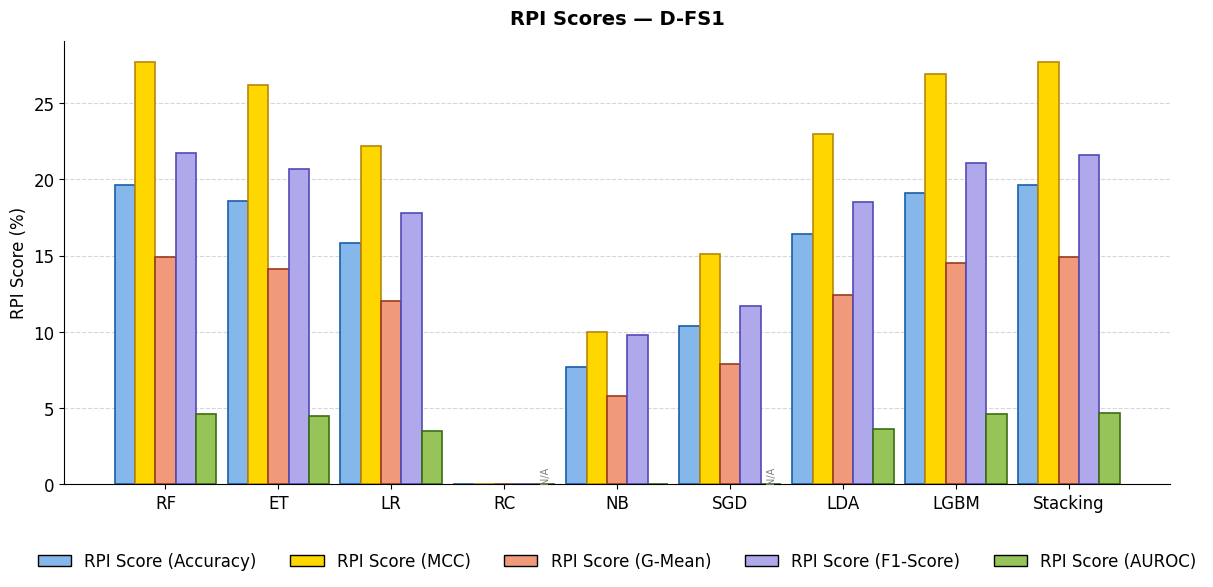

Saved: rpi_D_FS1.png


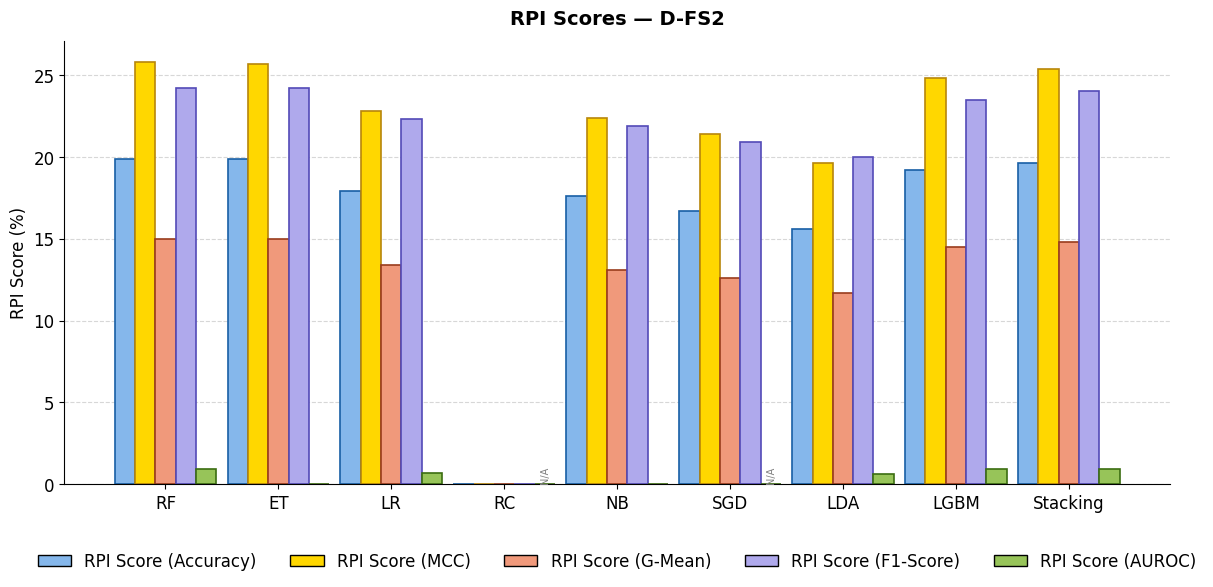

Saved: rpi_D_FS2.png


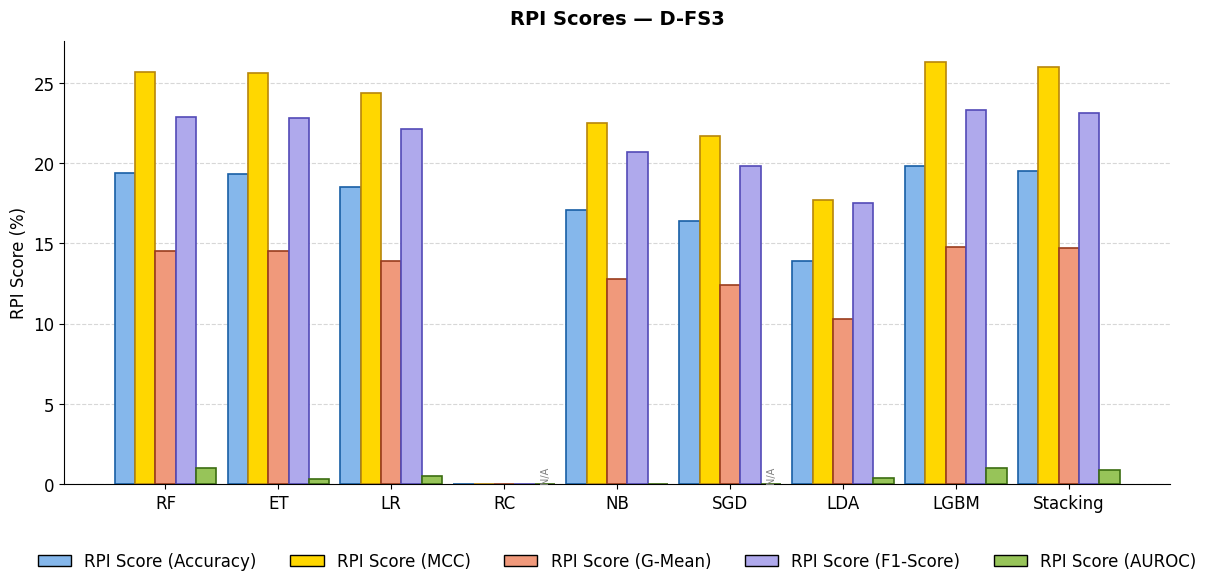

Saved: rpi_D_FS3.png


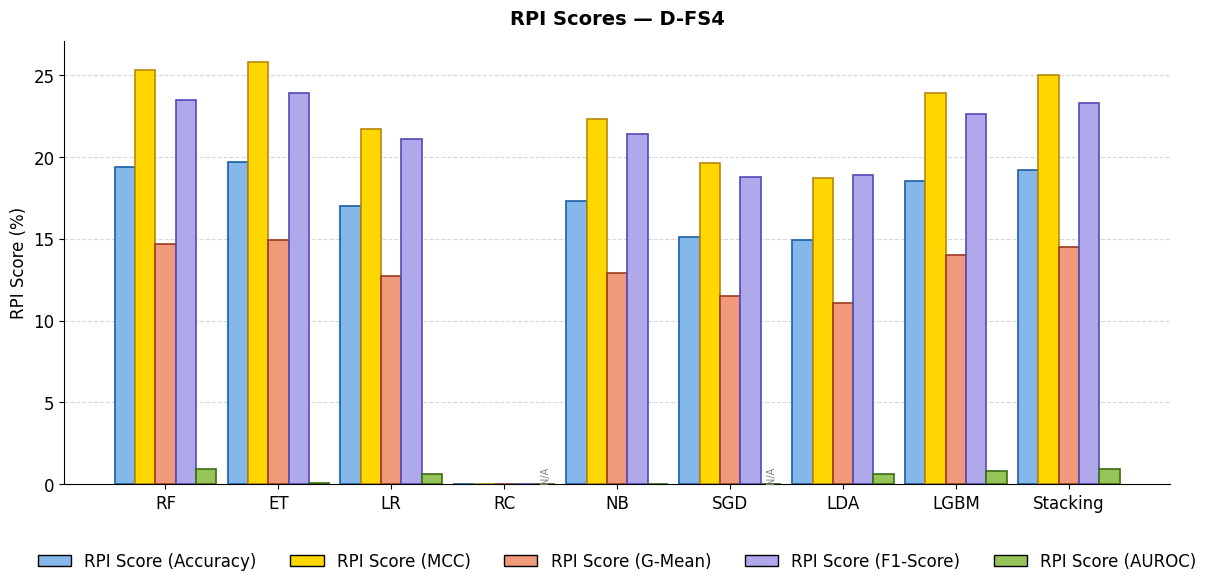

Saved: rpi_D_FS4.png


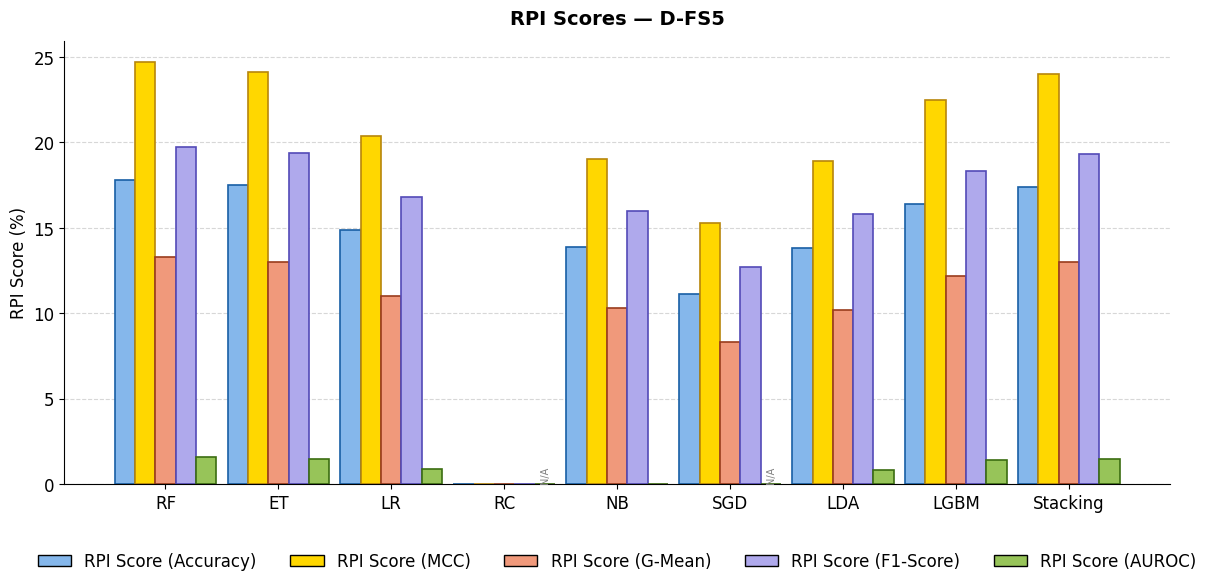

Saved: rpi_D_FS5.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

raw = {
    "D-FS1": {
        "RF":       [0.938, 0.909, 0.953, 0.938, 0.993],
        "ET":       [0.928, 0.894, 0.945, 0.928, 0.992],
        "LR":       [0.900, 0.854, 0.924, 0.899, 0.982],
        "RC":       [0.742, 0.632, 0.804, 0.721, None ],
        "NB":       [0.819, 0.732, 0.862, 0.819, 0.947],
        "SGD":      [0.846, 0.783, 0.883, 0.838, None ],
        "LDA":      [0.906, 0.862, 0.928, 0.906, 0.983],
        "LGBM":     [0.933, 0.901, 0.949, 0.932, 0.993],
        "Stacking": [0.938, 0.909, 0.953, 0.937, 0.994],
    },
    "D-FS2": {
        "RF":       [0.951, 0.928, 0.963, 0.950, 0.994],
        "ET":       [0.951, 0.927, 0.963, 0.950, 0.985],
        "LR":       [0.931, 0.898, 0.947, 0.931, 0.992],
        "RC":       [0.752, 0.670, 0.813, 0.708, None ],
        "NB":       [0.928, 0.894, 0.944, 0.927, 0.985],
        "SGD":      [0.919, 0.884, 0.939, 0.917, None ],
        "LDA":      [0.908, 0.866, 0.930, 0.908, 0.991],
        "LGBM":     [0.944, 0.918, 0.958, 0.943, 0.994],
        "Stacking": [0.948, 0.924, 0.961, 0.948, 0.994],
    },
    "D-FS3": {
        "RF":       [0.955, 0.933, 0.965, 0.954, 0.996],
        "ET":       [0.954, 0.932, 0.965, 0.953, 0.989],
        "LR":       [0.946, 0.920, 0.959, 0.946, 0.991],
        "RC":       [0.761, 0.676, 0.820, 0.725, None ],
        "NB":       [0.932, 0.901, 0.948, 0.932, 0.986],
        "SGD":      [0.925, 0.893, 0.944, 0.923, None ],
        "LDA":      [0.900, 0.853, 0.923, 0.900, 0.990],
        "LGBM":     [0.959, 0.939, 0.968, 0.958, 0.996],
        "Stacking": [0.956, 0.936, 0.967, 0.956, 0.995],
    },
    "D-FS4": {
        "RF":       [0.949, 0.925, 0.962, 0.949, 0.994],
        "ET":       [0.952, 0.930, 0.964, 0.953, 0.986],
        "LR":       [0.925, 0.889, 0.942, 0.925, 0.991],
        "RC":       [0.755, 0.672, 0.815, 0.714, None ],
        "NB":       [0.928, 0.895, 0.944, 0.928, 0.985],
        "SGD":      [0.906, 0.868, 0.930, 0.902, None ],
        "LDA":      [0.904, 0.859, 0.926, 0.903, 0.991],
        "LGBM":     [0.940, 0.911, 0.955, 0.940, 0.993],
        "Stacking": [0.947, 0.922, 0.960, 0.947, 0.994],
    },
    "D-FS5": {
        "RF":       [0.950, 0.927, 0.962, 0.949, 0.996],
        "ET":       [0.947, 0.921, 0.959, 0.946, 0.995],
        "LR":       [0.921, 0.884, 0.939, 0.920, 0.989],
        "RC":       [0.772, 0.680, 0.829, 0.752, None ],
        "NB":       [0.911, 0.870, 0.932, 0.912, 0.980],
        "SGD":      [0.883, 0.833, 0.912, 0.879, None ],
        "LDA":      [0.910, 0.869, 0.931, 0.910, 0.988],
        "LGBM":     [0.936, 0.905, 0.951, 0.935, 0.994],
        "Stacking": [0.946, 0.920, 0.959, 0.945, 0.995],
    },
}

datasets   = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models     = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics    = ["Accuracy", "MCC", "G-Mean", "F1-Score", "AUROC"]
metric_idx = {"Accuracy": 0, "MCC": 1, "G-Mean": 2, "F1-Score": 3, "AUROC": 4}

avg = {}
for ds in datasets:
    avg[ds] = {}
    for model in models:
        avg[ds][model] = {}
        for metric, k in metric_idx.items():
            avg[ds][model][metric] = raw[ds][model][k]

style = {
    "Accuracy": dict(color="#85B7EB", edgecolor="#185FA5", linewidth=1.2),
    "MCC":      dict(color="#FFD700", edgecolor="#B8860B", linewidth=1.2),
    "G-Mean":   dict(color="#F0997B", edgecolor="#993C1D", linewidth=1.2),
    "F1-Score": dict(color="#AFA9EC", edgecolor="#534AB7", linewidth=1.2),
    "AUROC":    dict(color="#97C459", edgecolor="#3B6D11", linewidth=1.2),
}

bar_width = 0.18
x         = np.arange(len(models))
n_metrics = len(metrics)
offsets   = np.linspace(-(n_metrics - 1) / 2,
                         (n_metrics - 1) / 2,
                         n_metrics) * bar_width

# ── একটা dataset এর জন্য RPI বের করার function ──────────────────────────────
def compute_rpi_single(ds):
    """
    Single-dataset RPI:
    RPI(model, metric) = (score - min_score_in_ds) * 100
    min is taken only over models that have a valid score.
    """
    rpi = {}
    for model in models:
        rpi[model] = {}
        for metric in metrics:
            valid = [avg[ds][m][metric] for m in models if avg[ds][m][metric] is not None]
            if not valid or avg[ds][model][metric] is None:
                rpi[model][metric] = None
            else:
                a_min = min(valid)
                rpi[model][metric] = (avg[ds][model][metric] - a_min) * 100
    return rpi

# ── 5টা আলাদা graph ──────────────────────────────────────────────────────────
for ds in datasets:
    rpi = compute_rpi_single(ds)

    fig, ax = plt.subplots(figsize=(13, 6))

    for j, metric in enumerate(metrics):
        vals = [rpi[model][metric] if rpi[model][metric] is not None else 0.0
                for model in models]
        ax.bar(x + offsets[j], vals, width=bar_width,
               label=metric, **style[metric])

        # None হলে "N/A" লেখা দেখাও
        for i, model in enumerate(models):
            if rpi[model][metric] is None:
                ax.text(x[i] + offsets[j], 0.05, "N/A",
                        ha="center", va="bottom", fontsize=7,
                        color="gray", rotation=90)

    ax.set_title(f"RPI Scores — {ds}", fontsize=14, fontweight="bold", pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=12)
    ax.set_ylabel("RPI Score (%)", fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles = [
        mpatches.Patch(label=f"RPI Score ({m})",
                       facecolor=style[m]["color"],
                       edgecolor="black")
        for m in metrics
    ]
    ax.legend(handles=handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.12), ncol=5,
              fontsize=12, frameon=False)

    plt.tight_layout()
    fname = f"rpi_{ds.replace('-', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

Critical Diagram Of Classifiers


Significantly different pairs:
  RF vs SGD
  RF vs RC
  Stacking vs RC
  ET vs RC
  LGBM vs RC


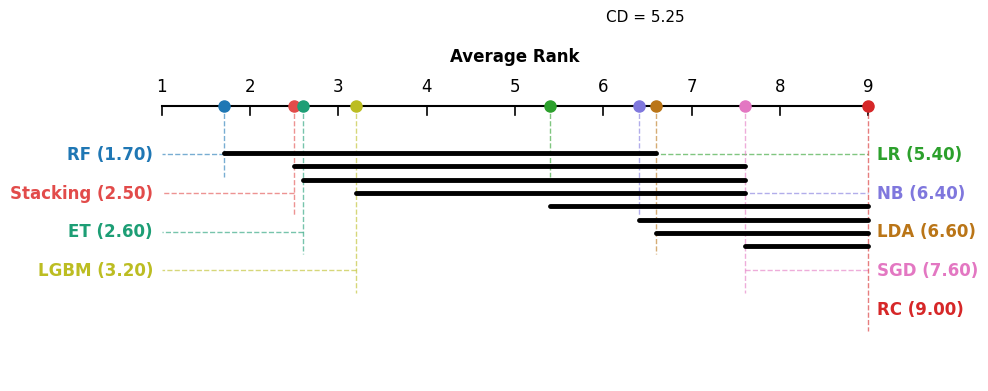

Done. Saved as cd_diagram.png


In [ ]:
n_methods = len(models)
# Removed n_metrics = 4 as it's not used and inconsistent with len(metrics)

scores = np.zeros((len(datasets), len(models)))

for i, ds in enumerate(datasets):
    for j, model in enumerate(models):
        model_performance_tuples = raw[ds][model]
        valid_means = [t[0] for t in model_performance_tuples if t is not None]
        if valid_means:
            scores[i, j] = np.mean(valid_means)
        else:
            scores[i, j] = np.nan # Assign NaN if all metrics are None for this model/dataset

ranks = np.zeros_like(scores)
for i in range(len(datasets)):
    # higher score = better → negate for ascending rank
    ranks[i] = rankdata(-scores[i])

mean_ranks = ranks.mean(axis=0)
N = len(datasets)
k = len(models)


#Friedman_Test
stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(k)])

#Nemenyi_Test
q_alpha = 3.03   # Nemenyi, alpha=0.05, k=9 (updated from 2.850 for k=6)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

sorted_idx   = np.argsort(mean_ranks)
sorted_names = [models[i] for i in sorted_idx]
sorted_ranks = mean_ranks[sorted_idx]

sig_pairs = []
for (i, j) in combinations(range(k), 2):
    if abs(sorted_ranks[i] - sorted_ranks[j]) > CD:
        sig_pairs.append((sorted_names[i], sorted_names[j]))

print("\nSignificantly different pairs:")
for p in sig_pairs:
    print(f"  {p[0]} vs {p[1]}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0.5, k + 0.5)
ax.set_ylim(-2.5, 2.0)
ax.axis("off")

axis_y = 1.2
ax.plot([1, k], [axis_y, axis_y], color="black", lw=1.5)
for r in range(1, k + 1):
    ax.plot([r, r], [axis_y, axis_y - 0.12], color="black", lw=1.2)
    ax.text(r, axis_y + 0.15, str(r), ha="center", va="bottom",
            fontsize=12, color="black")
ax.text((1 + k) / 2, axis_y + 0.55, "Average Rank",
        ha="center", va="bottom", fontsize=12, fontweight="bold")

cd_x_start = k - CD + 0.1
cd_y       = axis_y + 0.95
ax.annotate("", xy=(k + 0.1, cd_y),
            xytext=(cd_x_start, cd_y),
            arrowprops=dict(arrowstyle="-", color="black", lw=1.5))
ax.plot([cd_x_start, cd_x_start], [cd_y - 0.08, cd_y + 0.08],
        color="black", lw=1.5)
ax.plot([k + 0.1, k + 0.1], [cd_y - 0.08, cd_y + 0.08],
        color="black", lw=1.5)
ax.text((cd_x_start + k + 0.1) / 2, cd_y + 0.15,
        f"CD = {CD:.2f}", ha="center", va="bottom", fontsize=11)

# Updated colors_map to include all models and remove unused ones
initial_colors_map = {
    "ET":       "#1D9E75",
    "NB":       "#7F77DD",
    "LDA":      "#BA7517",
    "Stacking": "#E24B4A",
}

num_models_to_color = len(models)
# Use a colormap to get distinct colors
# 'tab10' provides 10 distinct colors, which is enough for 9 models
cmap = plt.colormaps['tab10'].resampled(num_models_to_color)

colors_map = {}
for idx, model_name in enumerate(models):
    if model_name in initial_colors_map:
        colors_map[model_name] = initial_colors_map[model_name]
    else:
        colors_map[model_name] = mcolors.to_hex(cmap(idx))

# split labels: top half left side, bottom half right side
n_left  = k // 2
n_right = k - n_left

label_y_top    =  0.55
label_y_step   =  0.52
line_drop      = -0.30

for pos, (name, rank) in enumerate(zip(sorted_names, sorted_ranks)):
    color = colors_map[name]
    # dot on axis
    ax.plot(rank, axis_y, "o", color=color, ms=8, zorder=5)

    if pos < n_left:
        # left side — labels go above-left
        ly = label_y_top - pos * label_y_step
        ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                color=color, lw=1.0, ls="--", alpha=0.6)
        ax.plot([rank, 1.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
        ax.text(0.9, ly, f"{name} ({rank:.2f})",
                ha="right", va="center", fontsize=12,
                color=color, fontweight="bold")
    else:
        # right side — labels go above-right
        rpos = pos - n_left
        ly   = label_y_top - rpos * label_y_step
        ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                color=color, lw=1.0, ls="--", alpha=0.6)
        ax.plot([rank, k + 0.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
        ax.text(k + 0.1, ly, f"{name} ({rank:.2f})",
                ha="left", va="center", fontsize=12,
                color=color, fontweight="bold")

clique_y   = axis_y - 0.45
clique_step = 0.18
drawn = []

for i in range(k):
    group = [i]
    for j in range(i + 1, k):
        pair = (sorted_names[i], sorted_names[j])
        pair_r = (sorted_names[j], sorted_names[i])
        if pair not in sig_pairs and pair_r not in sig_pairs:
            group.append(j)
    if len(group) > 1:
        key = tuple(group)
        if key not in drawn:
            drawn.append(key)
            bar_y = clique_y - len(drawn) * clique_step
            x_start = sorted_ranks[group[0]]
            x_end   = sorted_ranks[group[-1]]
            ax.plot([x_start, x_end], [bar_y, bar_y],
                    color="black", lw=3.5, solid_capstyle="round")

sig_str = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.4f}"

plt.tight_layout()
plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight")
plt.show()
print("Done. Saved as cd_diagram.png")


  D-FS1  |  Friedman p = 0.0000  |  CD = 5.25
Significantly different pairs:
  Stacking vs SGD
  Stacking vs NB
  Stacking vs RC
  RF vs SGD
  RF vs NB
  RF vs RC
  LGBM vs RC


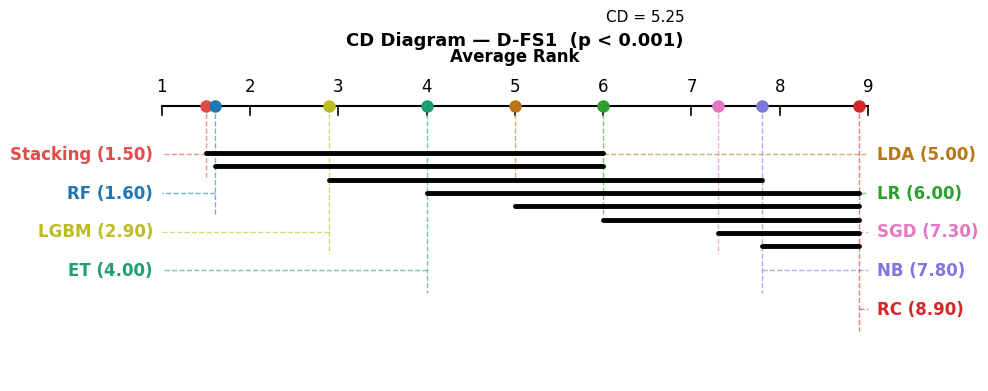

Saved: cd_D_FS1.png

  D-FS2  |  Friedman p = 0.0000  |  CD = 5.25
Significantly different pairs:
  RF vs SGD
  RF vs LDA
  RF vs RC
  ET vs RC
  Stacking vs RC
  LGBM vs RC


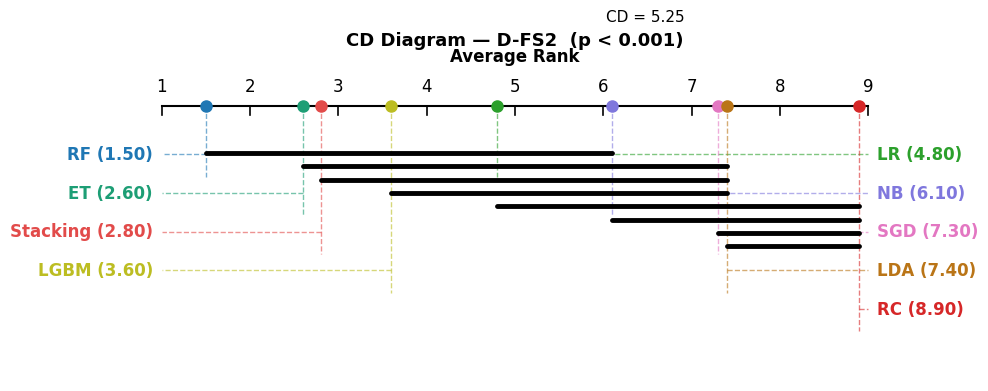

Saved: cd_D_FS2.png

  D-FS3  |  Friedman p = 0.0000  |  CD = 5.25
Significantly different pairs:
  LGBM vs SGD
  LGBM vs LDA
  LGBM vs RC
  Stacking vs RC
  RF vs RC


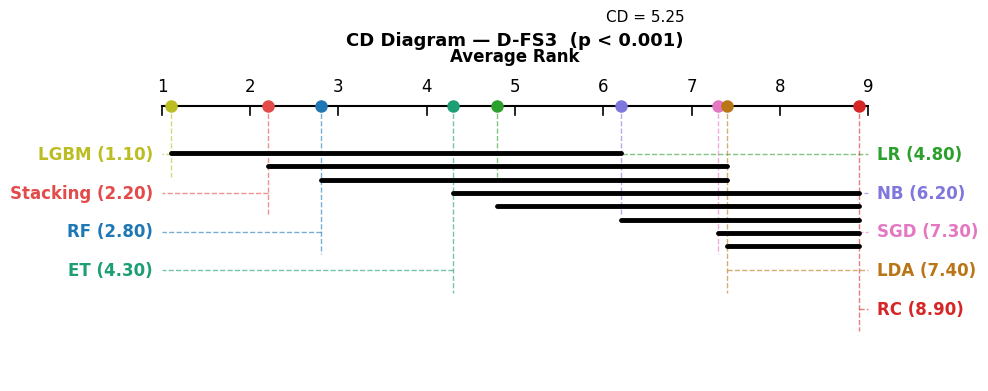

Saved: cd_D_FS3.png

  D-FS4  |  Friedman p = 0.0000  |  CD = 5.25
Significantly different pairs:
  RF vs SGD
  RF vs RC
  ET vs SGD
  ET vs RC
  Stacking vs RC


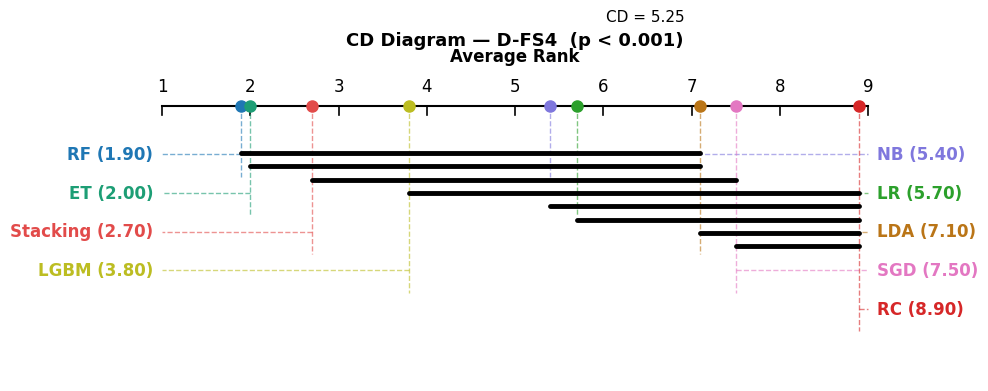

Saved: cd_D_FS4.png

  D-FS5  |  Friedman p = 0.0000  |  CD = 5.25
Significantly different pairs:
  RF vs LDA
  RF vs SGD
  RF vs RC
  ET vs SGD
  ET vs RC
  Stacking vs SGD
  Stacking vs RC


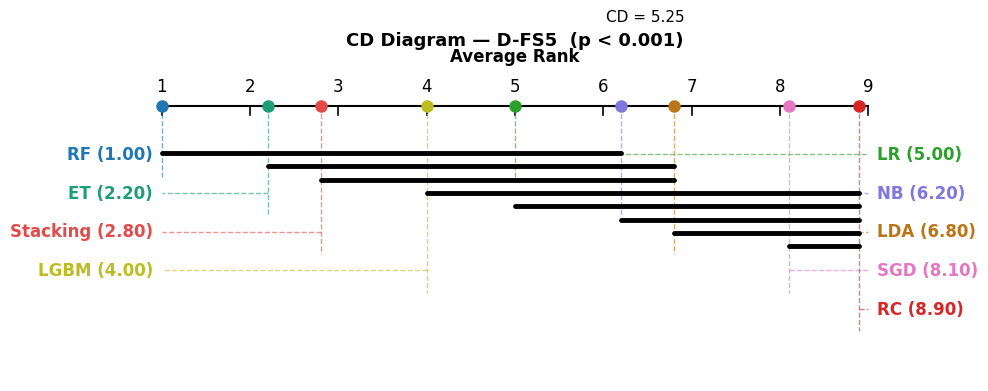

Saved: cd_D_FS5.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations

raw = {
    "D-FS1": {
        "RF":       [0.938, 0.909, 0.953, 0.938, 0.993],
        "ET":       [0.928, 0.894, 0.945, 0.928, 0.992],
        "LR":       [0.900, 0.854, 0.924, 0.899, 0.982],
        "RC":       [0.742, 0.632, 0.804, 0.721, None ],
        "NB":       [0.819, 0.732, 0.862, 0.819, 0.947],
        "SGD":      [0.846, 0.783, 0.883, 0.838, None ],
        "LDA":      [0.906, 0.862, 0.928, 0.906, 0.983],
        "LGBM":     [0.933, 0.901, 0.949, 0.932, 0.993],
        "Stacking": [0.938, 0.909, 0.953, 0.937, 0.994],
    },
    "D-FS2": {
        "RF":       [0.951, 0.928, 0.963, 0.950, 0.994],
        "ET":       [0.951, 0.927, 0.963, 0.950, 0.985],
        "LR":       [0.931, 0.898, 0.947, 0.931, 0.992],
        "RC":       [0.752, 0.670, 0.813, 0.708, None ],
        "NB":       [0.928, 0.894, 0.944, 0.927, 0.985],
        "SGD":      [0.919, 0.884, 0.939, 0.917, None ],
        "LDA":      [0.908, 0.866, 0.930, 0.908, 0.991],
        "LGBM":     [0.944, 0.918, 0.958, 0.943, 0.994],
        "Stacking": [0.948, 0.924, 0.961, 0.948, 0.994],
    },
    "D-FS3": {
        "RF":       [0.955, 0.933, 0.965, 0.954, 0.996],
        "ET":       [0.954, 0.932, 0.965, 0.953, 0.989],
        "LR":       [0.946, 0.920, 0.959, 0.946, 0.991],
        "RC":       [0.761, 0.676, 0.820, 0.725, None ],
        "NB":       [0.932, 0.901, 0.948, 0.932, 0.986],
        "SGD":      [0.925, 0.893, 0.944, 0.923, None ],
        "LDA":      [0.900, 0.853, 0.923, 0.900, 0.990],
        "LGBM":     [0.959, 0.939, 0.968, 0.958, 0.996],
        "Stacking": [0.956, 0.936, 0.967, 0.956, 0.995],
    },
    "D-FS4": {
        "RF":       [0.949, 0.925, 0.962, 0.949, 0.994],
        "ET":       [0.952, 0.930, 0.964, 0.953, 0.986],
        "LR":       [0.925, 0.889, 0.942, 0.925, 0.991],
        "RC":       [0.755, 0.672, 0.815, 0.714, None ],
        "NB":       [0.928, 0.895, 0.944, 0.928, 0.985],
        "SGD":      [0.906, 0.868, 0.930, 0.902, None ],
        "LDA":      [0.904, 0.859, 0.926, 0.903, 0.991],
        "LGBM":     [0.940, 0.911, 0.955, 0.940, 0.993],
        "Stacking": [0.947, 0.922, 0.960, 0.947, 0.994],
    },
    "D-FS5": {
        "RF":       [0.950, 0.927, 0.962, 0.949, 0.996],
        "ET":       [0.947, 0.921, 0.959, 0.946, 0.995],
        "LR":       [0.921, 0.884, 0.939, 0.920, 0.989],
        "RC":       [0.772, 0.680, 0.829, 0.752, None ],
        "NB":       [0.911, 0.870, 0.932, 0.912, 0.980],
        "SGD":      [0.883, 0.833, 0.912, 0.879, None ],
        "LDA":      [0.910, 0.869, 0.931, 0.910, 0.988],
        "LGBM":     [0.936, 0.905, 0.951, 0.935, 0.994],
        "Stacking": [0.946, 0.920, 0.959, 0.945, 0.995],
    },
}

datasets = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models   = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics  = ["Accuracy", "MCC", "G-Mean", "F1-Score", "AUROC"]

# ── colors ────────────────────────────────────────────────────────────────────
initial_colors_map = {
    "ET":       "#1D9E75",
    "NB":       "#7F77DD",
    "LDA":      "#BA7517",
    "Stacking": "#E24B4A",
}
cmap = plt.colormaps['tab10'].resampled(len(models))
colors_map = {}
for idx, m in enumerate(models):
    colors_map[m] = initial_colors_map.get(m, mcolors.to_hex(cmap(idx)))

q_alpha = 3.03  # Nemenyi, alpha=0.05, k=9

# ── একটা dataset এর জন্য CD diagram ─────────────────────────────────────────
def plot_cd_diagram(ds):
    # প্রতিটা metric আলাদা "dataset" হিসেবে treat করা হচ্ছে
    # scores matrix: rows=metrics, cols=models
    metric_idx = {"Accuracy": 0, "MCC": 1, "G-Mean": 2, "F1-Score": 3, "AUROC": 4}

    scores = np.full((len(metrics), len(models)), np.nan)
    for i, metric in enumerate(metrics):
        k_idx = metric_idx[metric]
        for j, model in enumerate(models):
            val = raw[ds][model][k_idx]
            if val is not None:
                scores[i, j] = val

    # rank per metric row (ignore NaN — treat as worst)
    ranks = np.zeros_like(scores)
    for i in range(len(metrics)):
        row = scores[i]
        # NaN কে সবচেয়ে খারাপ score দিয়ে rank করা হচ্ছে
        filled = np.where(np.isnan(row), -np.inf, row)
        ranks[i] = rankdata(-filled)

    mean_ranks = ranks.mean(axis=0)
    N = len(metrics)   # number of "tasks" = 5 metrics
    k = len(models)

    # Friedman test
    stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(k)])

    # CD
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    sorted_idx   = np.argsort(mean_ranks)
    sorted_names = [models[i] for i in sorted_idx]
    sorted_ranks = mean_ranks[sorted_idx]

    sig_pairs = []
    for (i, j) in combinations(range(k), 2):
        if abs(sorted_ranks[i] - sorted_ranks[j]) > CD:
            sig_pairs.append((sorted_names[i], sorted_names[j]))

    print(f"\n{'='*40}")
    print(f"  {ds}  |  Friedman p = {p_value:.4f}  |  CD = {CD:.2f}")
    print(f"{'='*40}")
    print("Significantly different pairs:")
    for p in sig_pairs:
        print(f"  {p[0]} vs {p[1]}")

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlim(0.5, k + 0.5)
    ax.set_ylim(-2.5, 2.0)
    ax.axis("off")

    axis_y = 1.2
    ax.plot([1, k], [axis_y, axis_y], color="black", lw=1.5)
    for r in range(1, k + 1):
        ax.plot([r, r], [axis_y, axis_y - 0.12], color="black", lw=1.2)
        ax.text(r, axis_y + 0.15, str(r), ha="center", va="bottom",
                fontsize=12, color="black")
    ax.text((1 + k) / 2, axis_y + 0.55, "Average Rank",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

    # CD bar
    cd_x_start = k - CD + 0.1
    cd_y       = axis_y + 0.95
    ax.annotate("", xy=(k + 0.1, cd_y), xytext=(cd_x_start, cd_y),
                arrowprops=dict(arrowstyle="-", color="black", lw=1.5))
    ax.plot([cd_x_start, cd_x_start], [cd_y - 0.08, cd_y + 0.08], color="black", lw=1.5)
    ax.plot([k + 0.1, k + 0.1],       [cd_y - 0.08, cd_y + 0.08], color="black", lw=1.5)
    ax.text((cd_x_start + k + 0.1) / 2, cd_y + 0.15,
            f"CD = {CD:.2f}", ha="center", va="bottom", fontsize=11)

    # model labels
    n_left        = k // 2
    label_y_top   = 0.55
    label_y_step  = 0.52
    line_drop     = -0.30

    for pos, (name, rank) in enumerate(zip(sorted_names, sorted_ranks)):
        color = colors_map[name]
        ax.plot(rank, axis_y, "o", color=color, ms=8, zorder=5)

        if pos < n_left:
            ly = label_y_top - pos * label_y_step
            ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                    color=color, lw=1.0, ls="--", alpha=0.6)
            ax.plot([rank, 1.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
            ax.text(0.9, ly, f"{name} ({rank:.2f})",
                    ha="right", va="center", fontsize=12,
                    color=color, fontweight="bold")
        else:
            rpos = pos - n_left
            ly   = label_y_top - rpos * label_y_step
            ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                    color=color, lw=1.0, ls="--", alpha=0.6)
            ax.plot([rank, k + 0.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
            ax.text(k + 0.1, ly, f"{name} ({rank:.2f})",
                    ha="left", va="center", fontsize=12,
                    color=color, fontweight="bold")

    # clique bars (non-significantly different groups)
    clique_y    = axis_y - 0.45
    clique_step = 0.18
    drawn = []

    for i in range(k):
        group = [i]
        for j in range(i + 1, k):
            pair   = (sorted_names[i], sorted_names[j])
            pair_r = (sorted_names[j], sorted_names[i])
            if pair not in sig_pairs and pair_r not in sig_pairs:
                group.append(j)
        if len(group) > 1:
            key = tuple(group)
            if key not in drawn:
                drawn.append(key)
                bar_y   = clique_y - len(drawn) * clique_step
                x_start = sorted_ranks[group[0]]
                x_end   = sorted_ranks[group[-1]]
                ax.plot([x_start, x_end], [bar_y, bar_y],
                        color="black", lw=3.5, solid_capstyle="round")

    sig_str = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.4f}"
    ax.set_title(f"CD Diagram — {ds}  ({sig_str})",
                 fontsize=13, fontweight="bold", y=0.98)

    plt.tight_layout()
    fname = f"cd_{ds.replace('-', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# ── 5টা dataset এর জন্য loop ─────────────────────────────────────────────────
for ds in datasets:
    plot_cd_diagram(ds)

Heatmap Graph


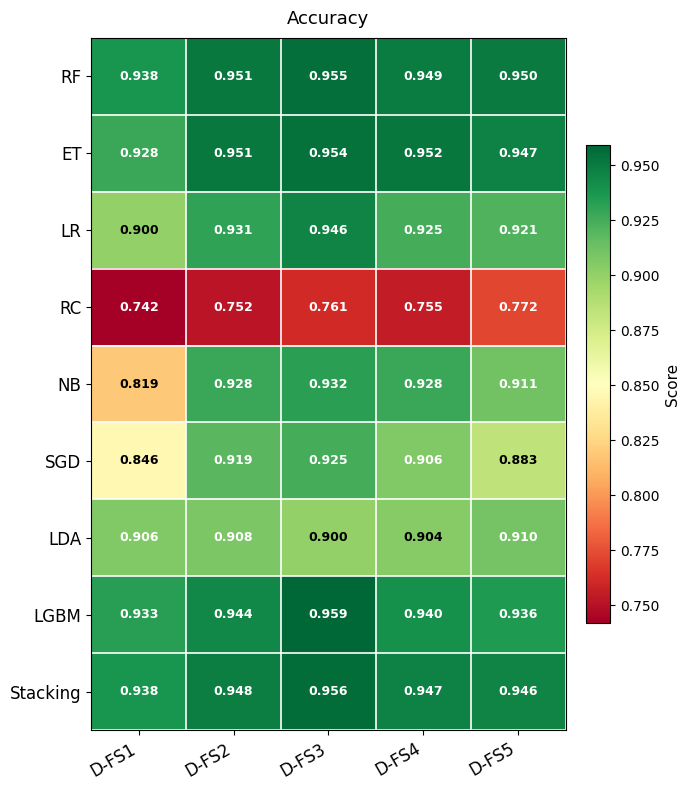

Saved: heatmap_Accuracy.png


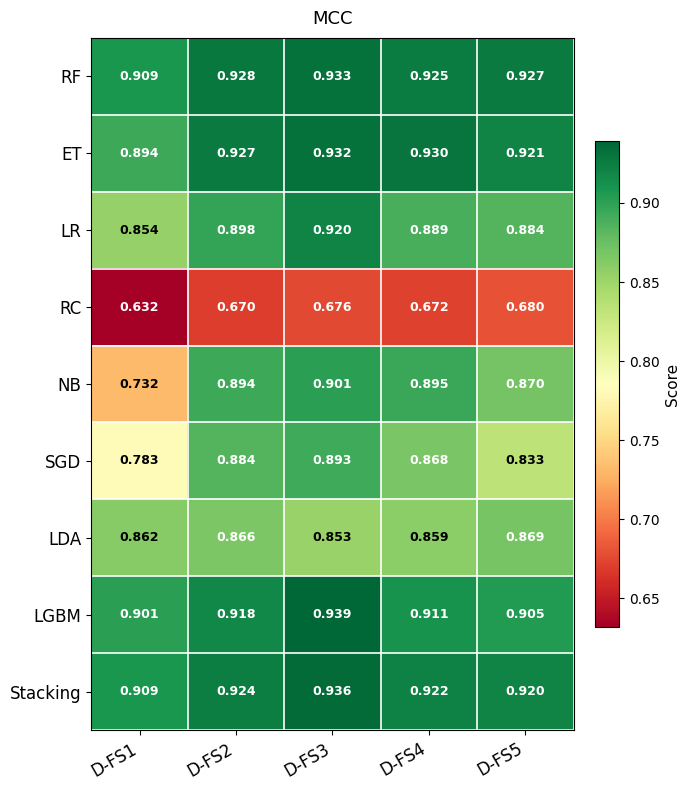

Saved: heatmap_MCC.png


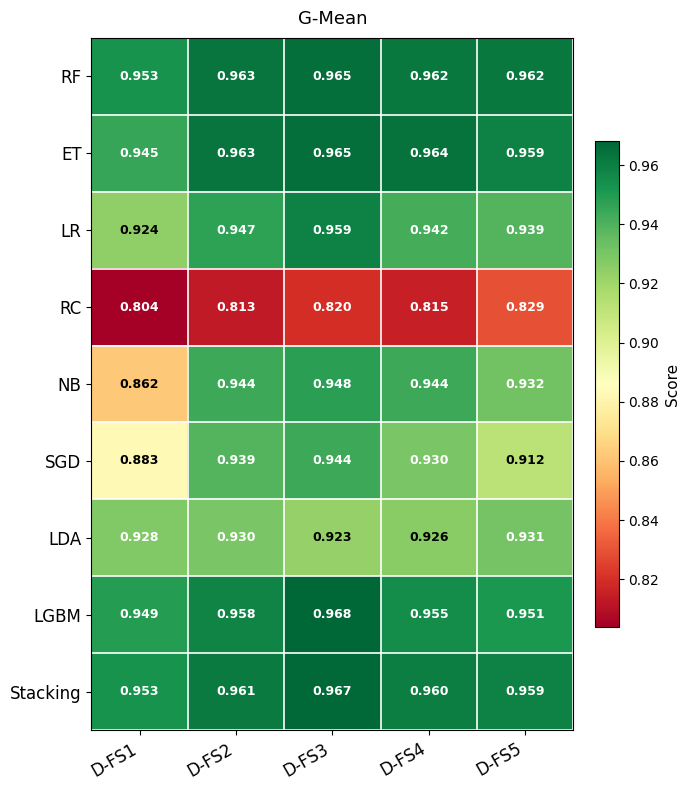

Saved: heatmap_G_Mean.png


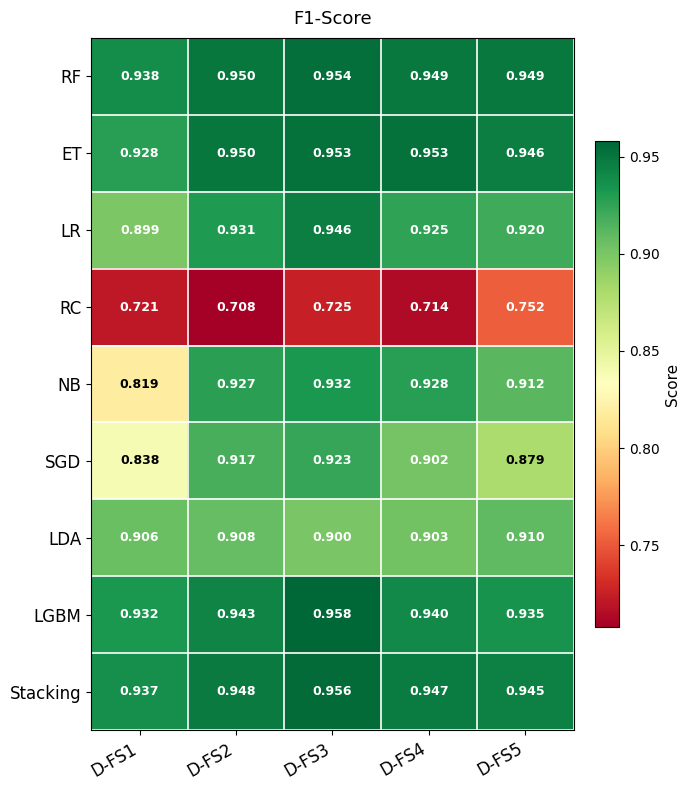

Saved: heatmap_F1_Score.png


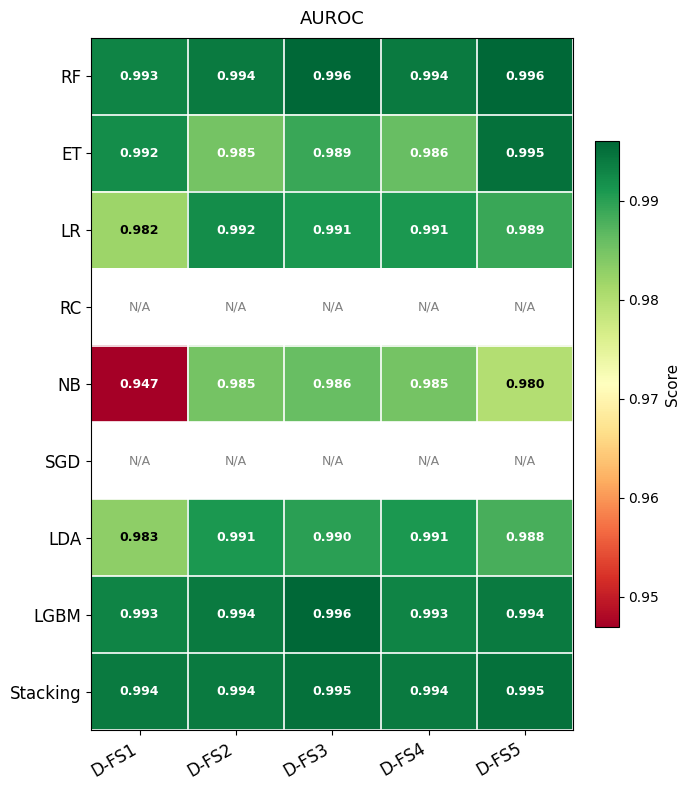

Saved: heatmap_AUROC.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ── DATA ──────────────────────────────────────────────────────────────────────

data = {
    "D-FS1": {
        "RF":       {"Accuracy":0.938,"MCC":0.909,"G-Mean":0.953,"F1-Score":0.938,"AUROC":0.993},
        "ET":       {"Accuracy":0.928,"MCC":0.894,"G-Mean":0.945,"F1-Score":0.928,"AUROC":0.992},
        "LR":       {"Accuracy":0.900,"MCC":0.854,"G-Mean":0.924,"F1-Score":0.899,"AUROC":0.982},
        "RC":       {"Accuracy":0.742,"MCC":0.632,"G-Mean":0.804,"F1-Score":0.721,"AUROC":None},
        "NB":       {"Accuracy":0.819,"MCC":0.732,"G-Mean":0.862,"F1-Score":0.819,"AUROC":0.947},
        "SGD":      {"Accuracy":0.846,"MCC":0.783,"G-Mean":0.883,"F1-Score":0.838,"AUROC":None},
        "LDA":      {"Accuracy":0.906,"MCC":0.862,"G-Mean":0.928,"F1-Score":0.906,"AUROC":0.983},
        "LGBM":     {"Accuracy":0.933,"MCC":0.901,"G-Mean":0.949,"F1-Score":0.932,"AUROC":0.993},
        "Stacking": {"Accuracy":0.938,"MCC":0.909,"G-Mean":0.953,"F1-Score":0.937,"AUROC":0.994},
    },
    "D-FS2": {
        "RF":       {"Accuracy":0.951,"MCC":0.928,"G-Mean":0.963,"F1-Score":0.950,"AUROC":0.994},
        "ET":       {"Accuracy":0.951,"MCC":0.927,"G-Mean":0.963,"F1-Score":0.950,"AUROC":0.985},
        "LR":       {"Accuracy":0.931,"MCC":0.898,"G-Mean":0.947,"F1-Score":0.931,"AUROC":0.992},
        "RC":       {"Accuracy":0.752,"MCC":0.670,"G-Mean":0.813,"F1-Score":0.708,"AUROC":None},
        "NB":       {"Accuracy":0.928,"MCC":0.894,"G-Mean":0.944,"F1-Score":0.927,"AUROC":0.985},
        "SGD":      {"Accuracy":0.919,"MCC":0.884,"G-Mean":0.939,"F1-Score":0.917,"AUROC":None},
        "LDA":      {"Accuracy":0.908,"MCC":0.866,"G-Mean":0.930,"F1-Score":0.908,"AUROC":0.991},
        "LGBM":     {"Accuracy":0.944,"MCC":0.918,"G-Mean":0.958,"F1-Score":0.943,"AUROC":0.994},
        "Stacking": {"Accuracy":0.948,"MCC":0.924,"G-Mean":0.961,"F1-Score":0.948,"AUROC":0.994},
    },
    "D-FS3": {
        "RF":       {"Accuracy":0.955,"MCC":0.933,"G-Mean":0.965,"F1-Score":0.954,"AUROC":0.996},
        "ET":       {"Accuracy":0.954,"MCC":0.932,"G-Mean":0.965,"F1-Score":0.953,"AUROC":0.989},
        "LR":       {"Accuracy":0.946,"MCC":0.920,"G-Mean":0.959,"F1-Score":0.946,"AUROC":0.991},
        "RC":       {"Accuracy":0.761,"MCC":0.676,"G-Mean":0.820,"F1-Score":0.725,"AUROC":None},
        "NB":       {"Accuracy":0.932,"MCC":0.901,"G-Mean":0.948,"F1-Score":0.932,"AUROC":0.986},
        "SGD":      {"Accuracy":0.925,"MCC":0.893,"G-Mean":0.944,"F1-Score":0.923,"AUROC":None},
        "LDA":      {"Accuracy":0.900,"MCC":0.853,"G-Mean":0.923,"F1-Score":0.900,"AUROC":0.990},
        "LGBM":     {"Accuracy":0.959,"MCC":0.939,"G-Mean":0.968,"F1-Score":0.958,"AUROC":0.996},
        "Stacking": {"Accuracy":0.956,"MCC":0.936,"G-Mean":0.967,"F1-Score":0.956,"AUROC":0.995},
    },
    "D-FS4": {
        "RF":       {"Accuracy":0.949,"MCC":0.925,"G-Mean":0.962,"F1-Score":0.949,"AUROC":0.994},
        "ET":       {"Accuracy":0.952,"MCC":0.930,"G-Mean":0.964,"F1-Score":0.953,"AUROC":0.986},
        "LR":       {"Accuracy":0.925,"MCC":0.889,"G-Mean":0.942,"F1-Score":0.925,"AUROC":0.991},
        "RC":       {"Accuracy":0.755,"MCC":0.672,"G-Mean":0.815,"F1-Score":0.714,"AUROC":None},
        "NB":       {"Accuracy":0.928,"MCC":0.895,"G-Mean":0.944,"F1-Score":0.928,"AUROC":0.985},
        "SGD":      {"Accuracy":0.906,"MCC":0.868,"G-Mean":0.930,"F1-Score":0.902,"AUROC":None},
        "LDA":      {"Accuracy":0.904,"MCC":0.859,"G-Mean":0.926,"F1-Score":0.903,"AUROC":0.991},
        "LGBM":     {"Accuracy":0.940,"MCC":0.911,"G-Mean":0.955,"F1-Score":0.940,"AUROC":0.993},
        "Stacking": {"Accuracy":0.947,"MCC":0.922,"G-Mean":0.960,"F1-Score":0.947,"AUROC":0.994},
    },
    "D-FS5": {
        "RF":       {"Accuracy":0.950,"MCC":0.927,"G-Mean":0.962,"F1-Score":0.949,"AUROC":0.996},
        "ET":       {"Accuracy":0.947,"MCC":0.921,"G-Mean":0.959,"F1-Score":0.946,"AUROC":0.995},
        "LR":       {"Accuracy":0.921,"MCC":0.884,"G-Mean":0.939,"F1-Score":0.920,"AUROC":0.989},
        "RC":       {"Accuracy":0.772,"MCC":0.680,"G-Mean":0.829,"F1-Score":0.752,"AUROC":None},
        "NB":       {"Accuracy":0.911,"MCC":0.870,"G-Mean":0.932,"F1-Score":0.912,"AUROC":0.980},
        "SGD":      {"Accuracy":0.883,"MCC":0.833,"G-Mean":0.912,"F1-Score":0.879,"AUROC":None},
        "LDA":      {"Accuracy":0.910,"MCC":0.869,"G-Mean":0.931,"F1-Score":0.910,"AUROC":0.988},
        "LGBM":     {"Accuracy":0.936,"MCC":0.905,"G-Mean":0.951,"F1-Score":0.935,"AUROC":0.994},
        "Stacking": {"Accuracy":0.946,"MCC":0.920,"G-Mean":0.959,"F1-Score":0.945,"AUROC":0.995},
    },
}

# ── CONFIG ────────────────────────────────────────────────────────────────────

datasets = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models   = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics  = ["Accuracy", "MCC", "G-Mean", "F1-Score", "AUROC"]
cmap     = plt.cm.RdYlGn

# ── PLOT ──────────────────────────────────────────────────────────────────────

for metric in metrics:

    # grid: rows = models, cols = datasets
    grid = np.full((len(models), len(datasets)), np.nan)
    for j, ds in enumerate(datasets):
        for i, model in enumerate(models):
            val = data[ds][model][metric]
            if val is not None:
                grid[i, j] = val

    fig, ax = plt.subplots(figsize=(7, 8))

    masked = np.ma.masked_invalid(grid)
    vmin   = np.nanmin(grid)
    vmax   = np.nanmax(grid)

    im = ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    # cell annotation
    for i in range(len(models)):
        for j in range(len(datasets)):
            val = grid[i, j]
            if np.isnan(val):
                ax.text(j, i, "N/A", ha="center", va="center",
                        fontsize=9, color="gray")
            else:
                norm_val = (val - vmin) / (vmax - vmin)
                txt_col  = "white" if (norm_val < 0.25 or norm_val > 0.75) else "black"
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=9, color=txt_col, fontweight="bold")

    ax.set_xticks(range(len(datasets)))
    ax.set_xticklabels(datasets, fontsize=12, rotation=30, ha="right")
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=12)
    ax.set_title(f"{metric}", fontsize=13, pad=10)

    # grid lines
    ax.set_xticks(np.arange(-0.5, len(datasets), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(models), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=10)
    cb.set_label("Score", fontsize=11)

    plt.tight_layout()
    fname = f"heatmap_{metric.replace('-', '_').replace(' ', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")